<a href="https://colab.research.google.com/github/Meghana-200502/NNDL/blob/main/CNN-toy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TensorFlow version: 2.19.0
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape : (10000, 32, 32, 3)
y_test shape : (10000, 1)


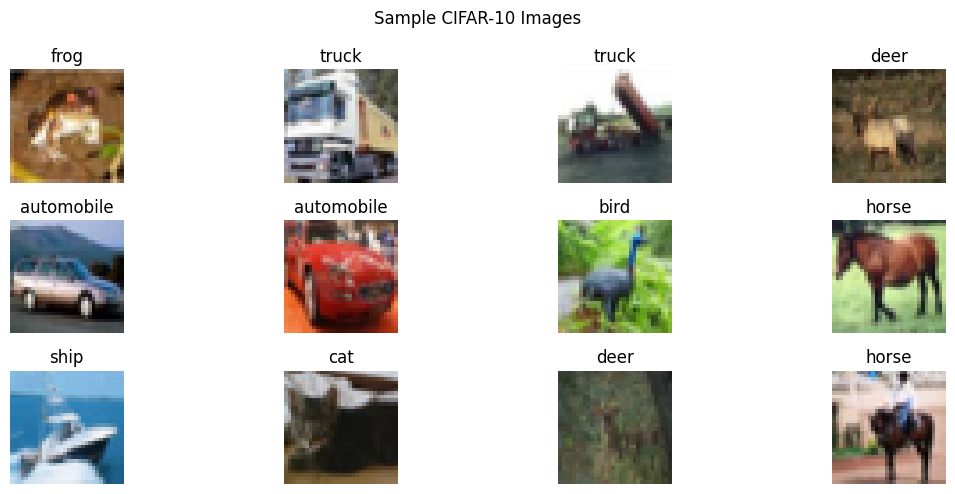

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2
625/625 ━━━━━━━━━━━━━━━━━━━━ 114s 179ms/step - accuracy: 0.4019 - loss: 1.6349 - val_accuracy: 0.5564 - val_loss: 1.2442
Epoch 2/2
625/625 ━━━━━━━━━━━━━━━━━━━━ 136s 170ms/step - accuracy: 0.5675 - loss: 1.2128 - val_accuracy: 0.6302 - val_loss: 1.0492

Test Accuracy: 0.6271
Test Loss    : 1.0494


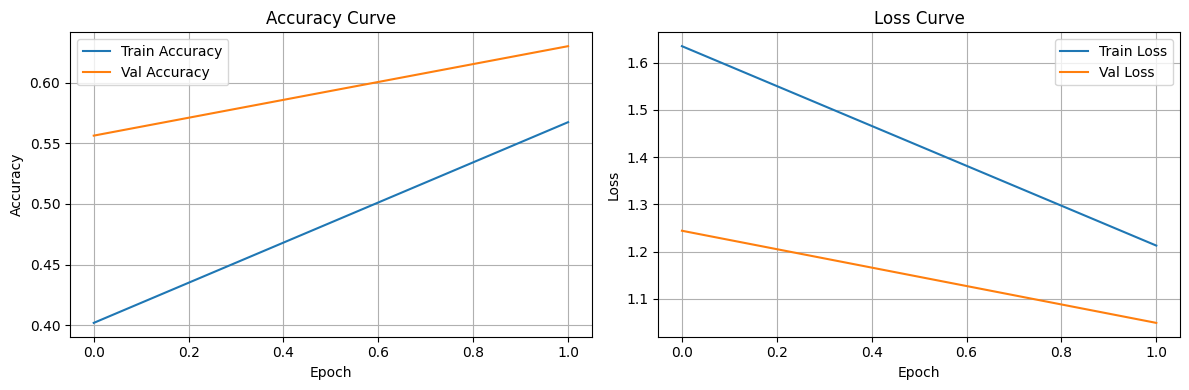

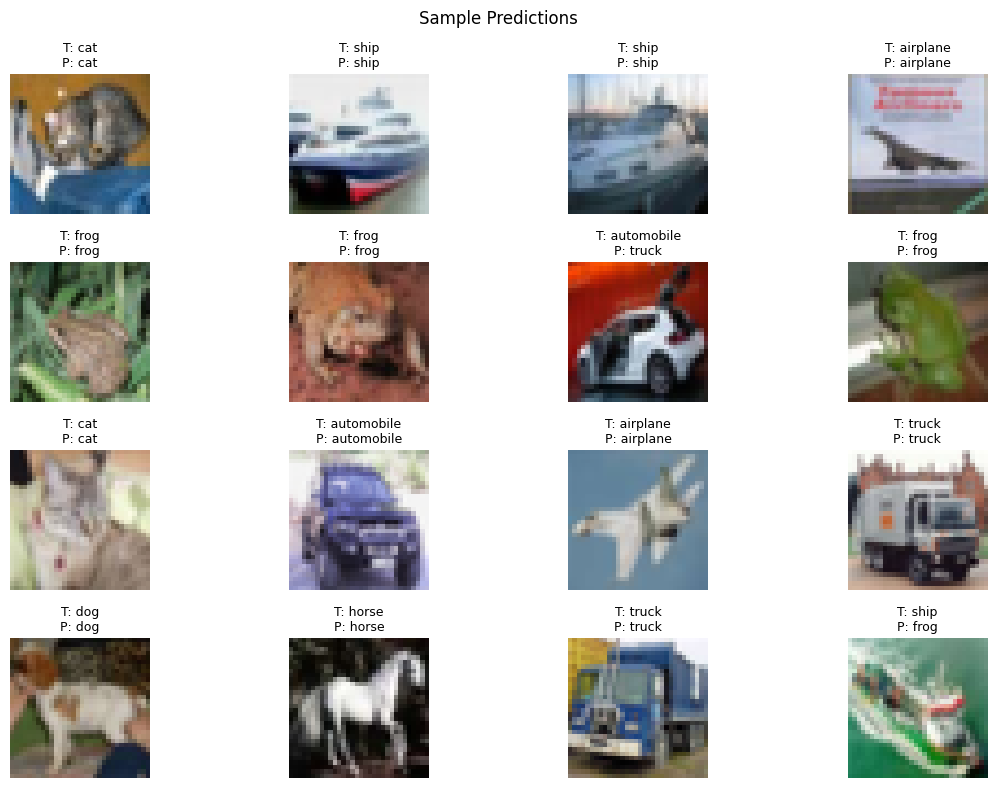

Filter shape: (3, 3, 3, 32)


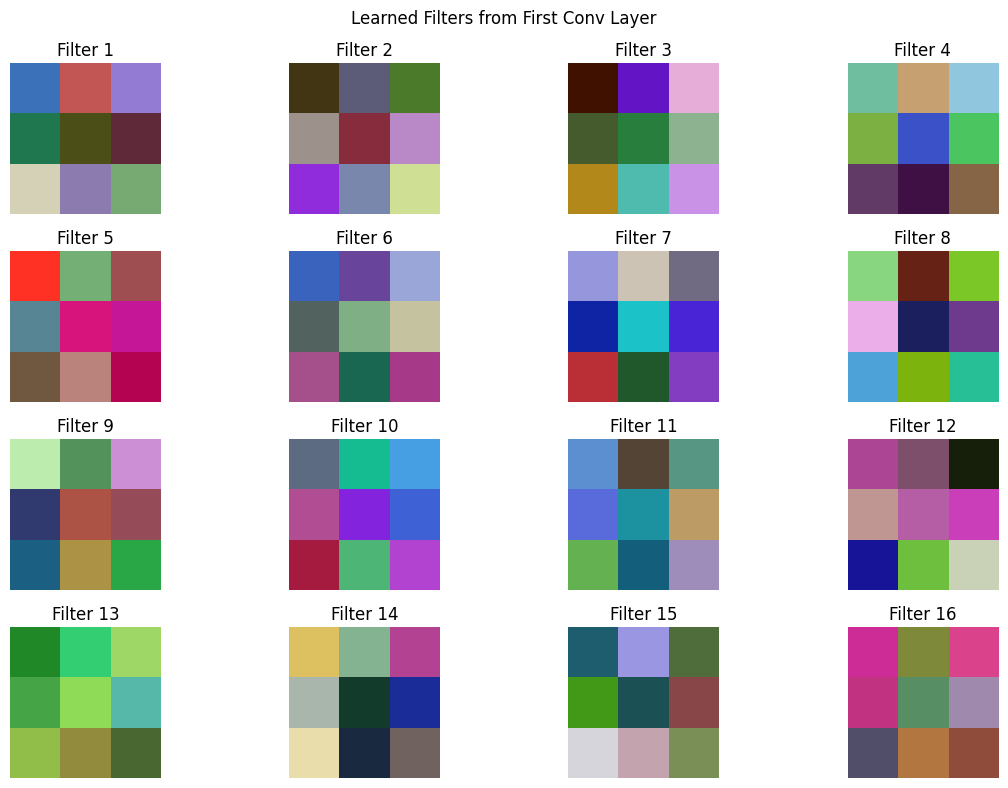

AttributeError: The layer sequential_1 has never been called and thus has no defined input.

In [24]:
# ============================================================
# 1) Install / import
# ============================================================
!pip -q install tensorflow matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

# ============================================================
# 2) Load CIFAR-10 dataset
#    No manual dataset upload needed
# ============================================================
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape :", x_test.shape)
print("y_test shape :", y_test.shape)

# Normalize to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# ============================================================
# 3) Show sample images
# ============================================================
plt.figure(figsize=(12, 5))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[int(y_train[i])])
    plt.axis("off")
plt.suptitle("Sample CIFAR-10 Images")
plt.tight_layout()
plt.show()

# ============================================================
# 4) Build CNN model
# ============================================================
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same', name="conv1"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name="conv2"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same', name="conv3"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ============================================================
# 5) Train model
# ============================================================
history = model.fit(
    x_train, y_train,
    epochs=2,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# ============================================================
# 6) Evaluate on test data
# ============================================================
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss    : {test_loss:.4f}")

# ============================================================
# 7) Plot training curves
# ============================================================
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ============================================================
# 8) Predict some test images
# ============================================================
pred_probs = model.predict(x_test[:16], verbose=0)
pred_labels = np.argmax(pred_probs, axis=1)

plt.figure(figsize=(12, 8))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(x_test[i])
    true_label = class_names[int(y_test[i])]
    pred_label = class_names[pred_labels[i]]
    plt.title(f"T: {true_label}\nP: {pred_label}", fontsize=9)
    plt.axis("off")
plt.suptitle("Sample Predictions")
plt.tight_layout()
plt.show()

# ============================================================
# 9) Visualize learned filters from first conv layer
# ============================================================
# First conv layer weights shape: (3, 3, 3, 32)
filters, biases = model.get_layer("conv1").get_weights()
print("Filter shape:", filters.shape)

# Normalize filters for display
f_min, f_max = filters.min(), filters.max()
filters_vis = (filters - f_min) / (f_max - f_min + 1e-8)

n_filters = filters_vis.shape[-1]

plt.figure(figsize=(12, 8))
for i in range(min(n_filters, 16)):
    plt.subplot(4, 4, i + 1)
    filt = filters_vis[:, :, :, i]
    plt.imshow(filt)
    plt.title(f"Filter {i+1}")
    plt.axis("off")
plt.suptitle("Learned Filters from First Conv Layer")
plt.tight_layout()
plt.show()

# ============================================================
# 10) Visualize feature maps
#     Shows what the CNN activates on
# ============================================================
sample_index = 0
sample_image = x_test[sample_index:sample_index+1]

layer_outputs = [
    model.get_layer("conv1").output,
    model.get_layer("conv2").output,
    model.get_layer("conv3").output
]

activation_model = tf.keras.Model(inputs=model.input, outputs=layer_outputs)
activations = activation_model.predict(sample_image, verbose=0)

plt.figure(figsize=(3, 3))
plt.imshow(x_test[sample_index])
plt.title(f"Input Image: {class_names[int(y_test[sample_index])]}")
plt.axis("off")
plt.show()

layer_names = ["conv1", "conv2", "conv3"]

for layer_name, activation in zip(layer_names, activations):
    n_maps = min(16, activation.shape[-1])

    plt.figure(figsize=(10, 10))
    for i in range(n_maps):
        plt.subplot(4, 4, i + 1)
        plt.imshow(activation[0, :, :, i], cmap="viridis")
        plt.title(f"{layer_name} map {i+1}", fontsize=8)
        plt.axis("off")
    plt.suptitle(f"Feature Maps from {layer_name}")
    plt.tight_layout()
    plt.show()

# ============================================================
# 11) Optional: visualize edge-like effect of first filters
#     Apply first conv layer directly to one image
# ============================================================
conv1_model = tf.keras.Model(inputs=model.input, outputs=model.get_layer("conv1").output)
conv1_output = conv1_model.predict(sample_image, verbose=0)

plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(conv1_output[0, :, :, i], cmap="gray")
    plt.title(f"Channel {i+1}", fontsize=8)
    plt.axis("off")
plt.suptitle("First-Layer Activations: Lines / Edges / Color Patterns")
plt.tight_layout()
plt.show()

# ============================================================
# 12) Show a few misclassified examples
# ============================================================
all_pred_probs = model.predict(x_test, verbose=0)
all_pred_labels = np.argmax(all_pred_probs, axis=1)

mis_idx = np.where(all_pred_labels != y_test.flatten())[0]

print("Number of misclassified samples:", len(mis_idx))

plt.figure(figsize=(12, 8))
for i, idx in enumerate(mis_idx[:12]):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[idx])
    true_label = class_names[int(y_test[idx])]
    pred_label = class_names[int(all_pred_labels[idx])]
    plt.title(f"T: {true_label}\nP: {pred_label}", fontsize=9)
    plt.axis("off")
plt.suptitle("Misclassified Test Images")
plt.tight_layout()
plt.show()